In [1]:
import pandas as pd   # used for loading data and working with dataframes/tables
import numpy as np    # used for numerical operations and array logic
import matplotlib.pyplot as plt  # used for plotting charts

# used to split the dataset into training and validation sets
from sklearn.model_selection import train_test_split

# preprocessing tools for turning raw tabular data into model-ready numeric data
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer

# evaluation metrics
from sklearn.metrics import (
    precision_score,           # how many predicted frauds were actually fraud
    recall_score,              # how many actual frauds we successfully caught
    f1_score,                  # balance between precision and recall
    confusion_matrix,          # shows TN, FP, FN, TP counts
    classification_report,     # detailed precision/recall/f1 report
    roc_auc_score,             # ranking metric across all thresholds
    average_precision_score    # PR AUC, very important for imbalanced fraud problems
)

# the final selected model from previous experiments
from xgboost import XGBClassifier

In [2]:
# Load the main transaction dataset
train_trans = pd.read_csv("../data/raw/train_transaction.csv")

# Load the identity dataset
train_id = pd.read_csv("../data/raw/train_identity.csv")

# Merge them together using TransactionID so each transaction
# gets matching identity/device information if available
df = train_trans.merge(train_id, on="TransactionID", how="left")

# Print the shape so we know the merge worked
print(df.shape)

# Show the first few rows for inspection
df.head()

(590540, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [3]:
# y is the target column we want to predict
# 0 = non-fraud, 1 = fraud
y = df["isFraud"]

# X contains the input features
# Drop isFraud because that is the answer column
# Drop TransactionID because it is just an ID, not a meaningful signal
X = df.drop(columns=["isFraud", "TransactionID"])

# Check shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (590540, 432)
y shape: (590540,)


In [4]:
# Compute the fraction of missing values in each column
missing_pct = X.isnull().mean()

# Find columns where more than 90% of values are missing
# These columns are usually too empty to be helpful
high_missing_cols = missing_pct[missing_pct > 0.90].index.tolist()

# Print how many columns we are removing
print("Dropping", len(high_missing_cols), "columns with >90% missing values")

# Drop those columns
X = X.drop(columns=high_missing_cols)

# Print the new shape after dropping them
print("New X shape:", X.shape)

Dropping 12 columns with >90% missing values
New X shape: (590540, 420)


In [6]:
# Get a list of numeric columns
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()

# Get a list of categorical/text columns
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

# Print the counts so we know how many of each type we have
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 391
Categorical features: 29


C:\Users\hariv\AppData\Local\Temp\ipykernel_65052\406595622.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


In [7]:
# Split the data into train and validation sets
# test_size=0.2 means 80% train, 20% validation
# stratify=y keeps the fraud rate similar in both sets
# random_state=42 makes the split reproducible
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Print shapes and fraud rates
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("Fraud rate train:", y_train.mean())
print("Fraud rate val:", y_val.mean())

X_train: (472432, 420)
X_val: (118108, 420)
Fraud rate train: 0.03498916246147594
Fraud rate val: 0.0349933958749619


In [8]:
# Create an imputer for numeric columns
# strategy="median" means fill missing numeric values with the median of that column
num_imputer = SimpleImputer(strategy="median")

# Fit the imputer on training numeric columns, then transform them
# Important: only fit on training data to avoid leakage
X_train_num = pd.DataFrame(
    num_imputer.fit_transform(X_train[numeric_features]),
    columns=numeric_features,
    index=X_train.index
)

# Use the same fitted imputer to transform validation numeric columns
X_val_num = pd.DataFrame(
    num_imputer.transform(X_val[numeric_features]),
    columns=numeric_features,
    index=X_val.index
)

# Print shapes to verify everything worked
print("X_train_num shape:", X_train_num.shape)
print("X_val_num shape:", X_val_num.shape)

X_train_num shape: (472432, 391)
X_val_num shape: (118108, 391)


In [10]:
# Create an imputer for categorical columns
# Fill missing values with the string "MISSING"
cat_imputer = SimpleImputer(strategy="constant", fill_value="MISSING")

# Fit on training categorical columns and transform them
X_train_cat_filled = pd.DataFrame(
    cat_imputer.fit_transform(X_train[categorical_features]),
    columns=categorical_features,
    index=X_train.index
)

# Use the same fitted imputer on validation categorical columns
X_val_cat_filled = pd.DataFrame(
    cat_imputer.transform(X_val[categorical_features]),
    columns=categorical_features,
    index=X_val.index
)

# Create an ordinal encoder
# This converts each category string into an integer code
# unknown_value=-1 means if validation has a new category unseen in training,
# it will be encoded as -1 instead of crashing
cat_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

# Fit encoder on training data and transform training categories
X_train_cat = pd.DataFrame(
    cat_encoder.fit_transform(X_train_cat_filled),
    columns=categorical_features,
    index=X_train.index
)

# Transform validation categories using the same fitted encoder
X_val_cat = pd.DataFrame(
    cat_encoder.transform(X_val_cat_filled),
    columns=categorical_features,
    index=X_val.index
)

# Print shapes
print("X_train_cat shape:", X_train_cat.shape)
print("X_val_cat shape:", X_val_cat.shape)

X_train_cat shape: (472432, 29)
X_val_cat shape: (118108, 29)


In [11]:
# Combine the processed numeric columns and processed categorical columns side by side
# This gives us the final model-ready feature matrices
X_train_processed = pd.concat([X_train_num, X_train_cat], axis=1)
X_val_processed = pd.concat([X_val_num, X_val_cat], axis=1)

# Print shapes to verify everything combined correctly
print("X_train_processed:", X_train_processed.shape)
print("X_val_processed:", X_val_processed.shape)

X_train_processed: (472432, 420)
X_val_processed: (118108, 420)


In [13]:
# Count how many non-fraud examples are in the training set
neg_count = (y_train == 0).sum()

# Count how many fraud examples are in the training set
pos_count = (y_train == 1).sum()

# Compute the imbalance ratio
# This tells XGBoost that fraud is much rarer and should get more weight
scale_pos_weight = neg_count / pos_count

# Print the values
print("Negative count:", neg_count)
print("Positive count:", pos_count)
print("scale_pos_weight:", scale_pos_weight)

Negative count: 455902
Positive count: 16530
scale_pos_weight: 27.580278281911674


In [14]:
# Recreate the XGBoost model using the settings that performed best earlier
xgb_model = XGBClassifier(
    n_estimators=300,             # number of boosting trees
    max_depth=6,                  # maximum depth of each tree
    learning_rate=0.1,            # how much each tree contributes
    subsample=0.8,                # use 80% of rows per tree
    colsample_bytree=0.8,         # use 80% of columns per tree
    objective="binary:logistic",  # binary classification with probability output
    eval_metric="logloss",        # evaluation metric during training
    random_state=42,              # keeps results reproducible
    scale_pos_weight=scale_pos_weight,  # helps handle class imbalance
    n_jobs=-1                     # use all available CPU cores
)

# Train the model on the processed training data
xgb_model.fit(X_train_processed, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [15]:
# Predict fraud probabilities on the validation set
# [:, 1] means we are taking the probability for class 1 = fraud
y_proba_xgb = xgb_model.predict_proba(X_val_processed)[:, 1]

# Print probability-based evaluation metrics
# These do not depend on picking a single threshold yet
print("ROC AUC:", roc_auc_score(y_val, y_proba_xgb))
print("PR AUC:", average_precision_score(y_val, y_proba_xgb))
print("Average predicted fraud probability:", y_proba_xgb.mean())

ROC AUC: 0.951256927812655
PR AUC: 0.7136379852421926
Average predicted fraud probability: 0.19056074


In [16]:
# These are the probability cutoffs we want to test
# Example: threshold 0.3 means classify as fraud if probability >= 0.3
thresholds_to_test = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

print("Thresholds to test:")
print(thresholds_to_test)

Thresholds to test:
[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


In [17]:
# We will store the results for each threshold in this list
results = []

# Loop through each threshold and see how the model behaves
for threshold in thresholds_to_test:
    # Convert probabilities into 0/1 fraud predictions using the current threshold
    # If fraud probability >= threshold, predict fraud (1); otherwise predict non-fraud (0)
    y_pred_threshold = (y_proba_xgb >= threshold).astype(int)

    # Calculate evaluation metrics for this threshold
    precision = precision_score(y_val, y_pred_threshold, zero_division=0)
    recall = recall_score(y_val, y_pred_threshold, zero_division=0)
    f1 = f1_score(y_val, y_pred_threshold, zero_division=0)

    # Save the threshold and metrics into our results list
    results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Predicted_Frauds": y_pred_threshold.sum()
    })

# Turn the list of results into a dataframe so it is easy to read
threshold_results = pd.DataFrame(results)

# Show the table
threshold_results

,Threshold,Precision,Recall,F1,Predicted_Frauds
0,0.1,0.063769,0.984031,0.119776,63777
1,0.2,0.107143,0.948706,0.192541,36596
2,0.3,0.161974,0.907573,0.274889,23158
3,0.4,0.227399,0.869102,0.360480,15796
4,0.5,0.307341,0.829664,0.448528,11157
5,0.6,0.408828,0.786596,0.538022,7952
6,0.7,0.535778,0.724655,0.616065,5590
7,0.8,0.687648,0.634406,0.659955,3813
8,0.9,0.860474,0.517784,0.646526,2487


In [18]:
# Sort the threshold results from highest F1 score to lowest
# This helps us see which threshold gives the best balance of precision and recall
threshold_results.sort_values(by="F1", ascending=False)

,Threshold,Precision,Recall,F1,Predicted_Frauds
7,0.8,0.687648,0.634406,0.659955,3813
8,0.9,0.860474,0.517784,0.646526,2487
6,0.7,0.535778,0.724655,0.616065,5590
5,0.6,0.408828,0.786596,0.538022,7952
4,0.5,0.307341,0.829664,0.448528,11157
3,0.4,0.227399,0.869102,0.360480,15796
2,0.3,0.161974,0.907573,0.274889,23158
1,0.2,0.107143,0.948706,0.192541,36596
0,0.1,0.063769,0.984031,0.119776,63777


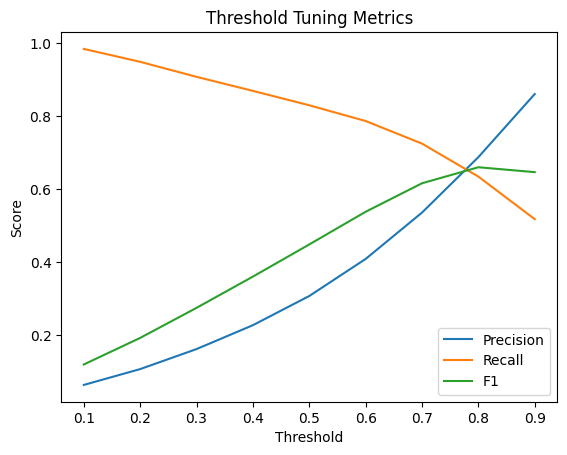

In [19]:
# Plot how precision changes as the threshold changes
plt.plot(threshold_results["Threshold"], threshold_results["Precision"], label="Precision")

# Plot how recall changes as the threshold changes
plt.plot(threshold_results["Threshold"], threshold_results["Recall"], label="Recall")

# Plot how F1 changes as the threshold changes
plt.plot(threshold_results["Threshold"], threshold_results["F1"], label="F1")

# Add axis labels and a title
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning Metrics")
plt.legend()

# Show the plot
plt.show()

In [20]:
# Find the single row with the highest F1 score
best_row = threshold_results.sort_values(by="F1", ascending=False).iloc[0]

print("Best threshold row:")
print(best_row)

Best threshold row:
Threshold              0.800000
Precision              0.687648
Recall                 0.634406
F1                     0.659955
Predicted_Frauds    3813.000000
Name: 7, dtype: float64


In [21]:
# Take the threshold from the best row
final_threshold = best_row["Threshold"]

# Convert probabilities into final 0/1 predictions using that threshold
y_pred_final = (y_proba_xgb >= final_threshold).astype(int)

# Print detailed evaluation at the chosen threshold
print("Chosen threshold:", final_threshold)

print("\nClassification Report at chosen threshold:")
print(classification_report(y_val, y_pred_final))

print("Confusion Matrix at chosen threshold:")
print(confusion_matrix(y_val, y_pred_final))

Chosen threshold: 0.8

Classification Report at chosen threshold:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    113975
           1       0.69      0.63      0.66      4133

    accuracy                           0.98    118108
   macro avg       0.84      0.81      0.82    118108
weighted avg       0.98      0.98      0.98    118108

Confusion Matrix at chosen threshold:
[[112784   1191]
 [  1511   2622]]


In [22]:
# This function maps a fraud probability into a risk category
def risk_band(prob):
    if prob < 0.30:
        return "Low Risk"
    elif prob < 0.70:
        return "Medium Risk"
    else:
        return "High Risk"

# Apply the risk band function to each validation probability
risk_band_series = pd.Series(y_proba_xgb).apply(risk_band)

# Show how many transactions fall into each risk category
print(risk_band_series.value_counts())

Low Risk       94950
Medium Risk    17568
High Risk       5590
Name: count, dtype: int64


In [23]:
# Create a results dataframe that could later be used in an app/dashboard
validation_results = pd.DataFrame({
    "fraud_probability": y_proba_xgb,                       # model score
    "risk_band": pd.Series(y_proba_xgb).apply(risk_band),  # low/medium/high risk label
    "actual_isFraud": y_val.values,                        # true fraud label
    "predicted_isFraud": y_pred_final                      # predicted label at chosen threshold
})

# Show the first 20 rows
validation_results.head(20)

,fraud_probability,risk_band,actual_isFraud,predicted_isFraud
0,0.040079,Low Risk,0,0
1,0.167224,Low Risk,0,0
2,0.063410,Low Risk,0,0
3,0.058910,Low Risk,0,0
4,0.030018,Low Risk,0,0
5,0.233758,Low Risk,0,0
6,0.128815,Low Risk,0,0
7,0.053140,Low Risk,0,0
8,0.068786,Low Risk,0,0
9,0.059599,Low Risk,0,0


In [24]:
# Count how many frauds were predicted at the chosen threshold
print("Predicted frauds at chosen threshold:", y_pred_final.sum())

# Count how many actual frauds are in validation
print("Actual frauds in validation:", y_val.sum())

# Print the average fraud probability from the model
print("Average predicted fraud probability:", y_proba_xgb.mean())

Predicted frauds at chosen threshold: 3813
Actual frauds in validation: 4133
Average predicted fraud probability: 0.19056074


## Threshold Tuning Notes

- Used the final XGBoost model to generate fraud probabilities on the validation set.
- Tested multiple probability thresholds instead of relying only on the default 0.5 cutoff.
- Compared precision, recall, F1-score, and predicted fraud counts at each threshold.
- Found that a threshold of 0.8 gave the strongest F1-score and a much more practical fraud precision/recall tradeoff.
- At threshold 0.8, the model achieved approximately 0.69 fraud precision, 0.63 fraud recall, and 0.66 fraud F1.
- Created low-, medium-, and high-risk bands from fraud probabilities to support deployment-style fraud screening.
- This threshold tuning step made the model more realistic for use in a dashboard or API.